# Class Weights — Rebalancing the Loss Instead of the Data

Resampling changes the dataset. **Class weighting** leaves the data alone and changes the
*objective*: each class's contribution to the loss is multiplied by a weight, so getting a rare
example wrong costs more than getting a common one wrong. Nothing is duplicated, nothing is
discarded, and the fit sees the real data exactly once.

The weight is a dial, not a setting, and this notebook turns it through its whole range — then
answers the question that sweep raises: **which value should you actually pick?** The honest answer
is that no metric can tell you; it depends on what the errors cost.

## Learning objectives

- Set per-class weights in a scikit-learn classifier and sweep them across their range
- Read how precision and recall for each class trade off as the weight moves
- Choose an operating point using a **reward matrix** encoding the real cost of each error type
- Use `class_weight='balanced'` and state the formula behind it

## Background

This notebook assumes precision, recall, and $F_1$ from `U1-6_Classify-3_F1Score`, the confusion
matrix, and the imbalance failure mode demonstrated in `U1-7_Imbalance-2_Resampling`. Class
weighting is an alternative to the resampling used there — same goal, different mechanism.

**Prerequisites:** `U1-6_Classify-3_F1Score` (precision/recall/$F_1$),
`U1-7_Imbalance-2_Resampling` (the imbalance failure this addresses)

**Dataset:** none — two 2-D Gaussian clouds from `GenerateData`, here at 1000:250 (4:1).

**References:** https://scikit-learn.org/stable/modules/svm.html#unbalanced-problems

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Tools: entropy, region painting, and the data generator

Three helpers carried across the imbalance notebooks.

`GenerateData(n_pts0, n_pts1, center_sep, std)` draws two 2-D Gaussian clouds with a controllable
**imbalance ratio** — the two counts are independent, so a 10:1 or 4:1 split is one argument away —
and a controllable **overlap** via `center_sep` and `std`. Imbalance and overlap are separate
problems and this lets us vary them separately.

`entropy` and `visualize_regions` are the decision-region tools from
`U1-6_Classify-1_CompareRegions`: predict on a dense grid, reshape into an image, and return both
the predicted class and the entropy of the predicted probabilities at each point.

In [2]:
import math

def entropy( x, b ):
    s = 0
    for p in x:
        if p > 0:
            s += -p*math.log(p,b)
        # end
    # end
    return s
# end

def visualize_regions(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)

    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T

    # Predict B
    B = model.predict(A)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)

    # Compute entropy for S
    prob_2D = model.predict_proba(A)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)

    return B, S
# end
    
def GenerateData(n_pts1,n_pts2,center_sep,std):
    
    cov = std**2*np.eye(2)
    
    x1 = np.random.multivariate_normal(mean=[-center_sep/2,0],
                                       cov=cov,
                                       size=n_pts1)
    y1 = np.zeros(n_pts1)
    
    x2 = np.random.multivariate_normal(mean=[center_sep/2,0],
                                       cov=cov,
                                       size=n_pts2)
    y2 = np.ones(n_pts2)
    
    X = np.concatenate((x1,x2),axis=0)
    y = np.concatenate((y1,y2),axis=0).astype(int)
    
    return X, y
# end

## 2. Create the data

A 4:1 imbalance this time — 1,000 against 250 — milder than the 10:1 of the resampling notebooks, so
the weight sweep has a visible effect across its whole range rather than saturating immediately.

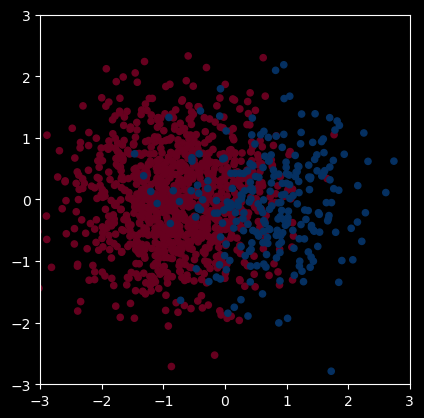

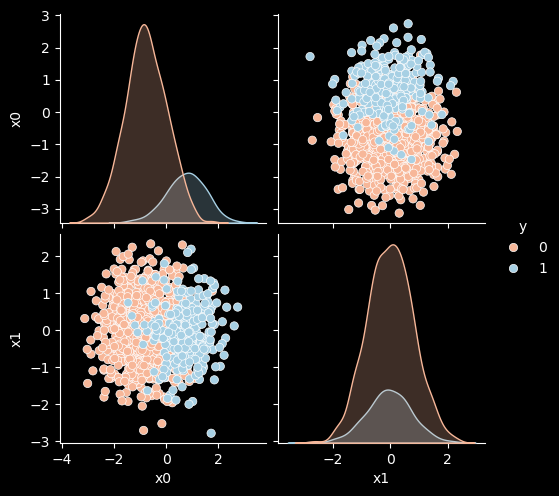

In [3]:
#np.random.seed(0)

n_pts0     = 1000
n_pts1     = 250
std        = 0.8
center_sep = 1.5

# generate data
X, y = GenerateData(
    n_pts0,
    n_pts1,
    center_sep,
    std
)

MAX = np.max(np.abs(X))

cmap = 'RdBu'

plt_scale = 3
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap=cmap)
plt.xlim(-plt_scale,plt_scale)
plt.ylim(-plt_scale,plt_scale)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame( {"x0":X[:,0], "x1":X[:,1], "y":y} )
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## 3. Sweeping the class weight

Weighting multiplies each class's contribution to the loss. For weights $w_0, w_1$ the objective
becomes

$$\mathcal{L} = -\sum_{i} w_{y_i} \log \hat{p}^{(i)}_{y_i}$$

so an error on a class with a larger weight is penalized proportionally more. The model is pushed to
predict the heavily weighted class more readily.

The sweep runs $w_1$ from near 0 to near 1 with $w_0 = 1 - w_1$, covering everything from "ignore
the minority class" to "ignore the majority class". Only the ratio matters, not the absolute scale —
$\{0: 2, 1: 8\}$ behaves identically to $\{0: 0.2, 1: 0.8\}$.

The cell also offers a commented `RandomForestClassifier` alongside the active
`LogisticRegression`, and running both is worthwhile: a linear model's boundary shifts smoothly as
the weight changes, while a tree ensemble responds in discrete jumps as splits reorganize.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report

n_plot = 15

w = np.linspace(0,1,n_plot+2)[1:-1]

w

array([0.0625, 0.125 , 0.1875, 0.25  , 0.3125, 0.375 , 0.4375, 0.5   ,
       0.5625, 0.625 , 0.6875, 0.75  , 0.8125, 0.875 , 0.9375])

LogisticRegression(class_weight={0: np.float64(0.9375), 1: np.float64(0.0625)})
              precision    recall  f1-score   support

           0       0.81      1.00      0.89       200
           1       1.00      0.06      0.11        50

    accuracy                           0.81       250
   macro avg       0.90      0.53      0.50       250
weighted avg       0.85      0.81      0.74       250



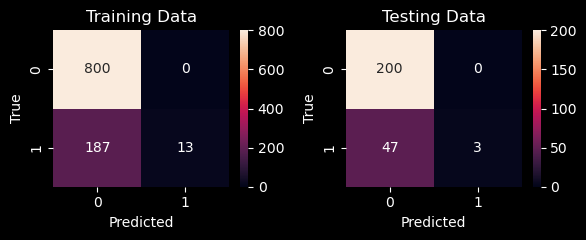

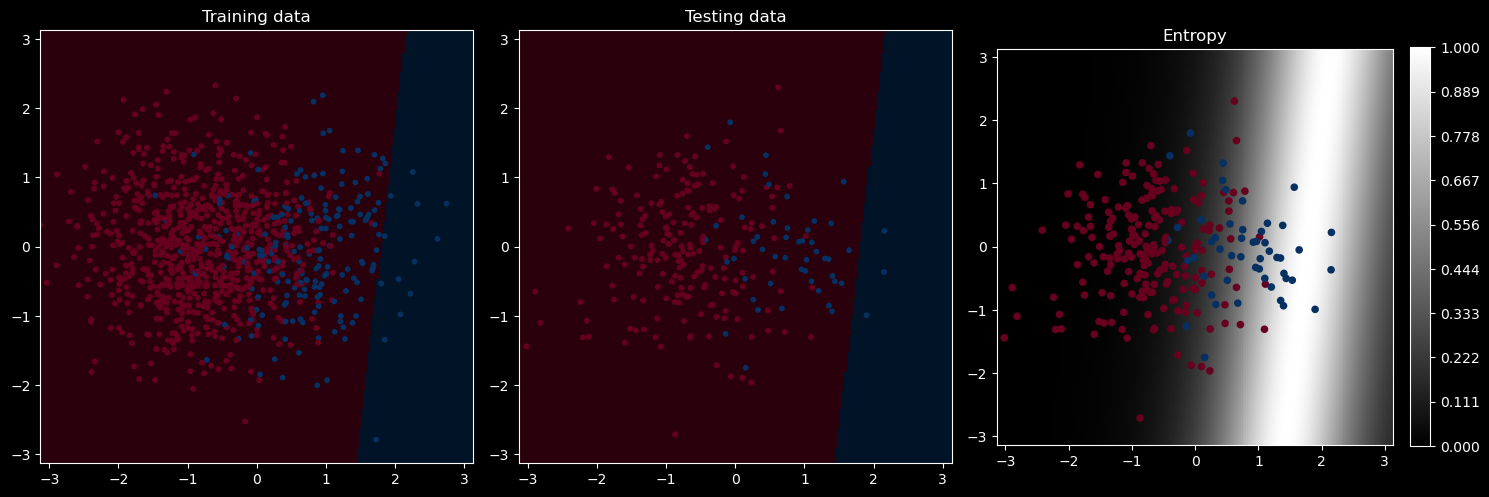



LogisticRegression(class_weight={0: np.float64(0.875), 1: np.float64(0.125)})
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       200
           1       1.00      0.20      0.33        50

    accuracy                           0.84       250
   macro avg       0.92      0.60      0.62       250
weighted avg       0.87      0.84      0.79       250



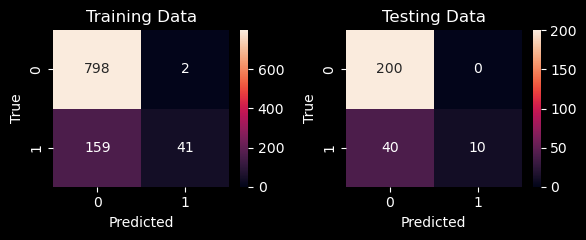

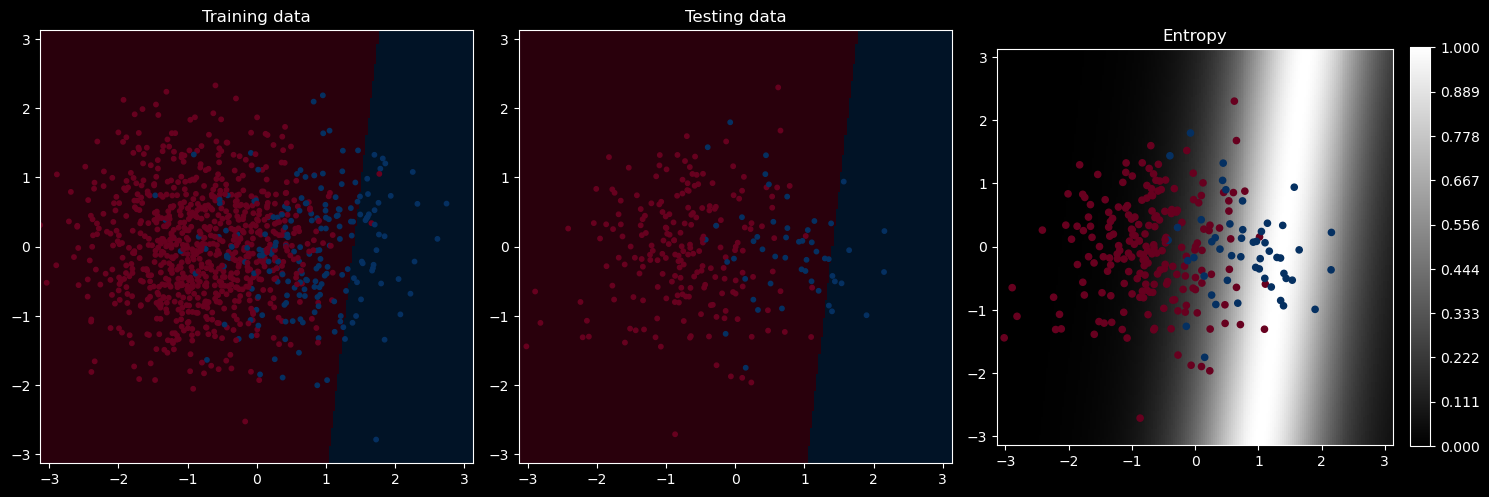



LogisticRegression(class_weight={0: np.float64(0.8125), 1: np.float64(0.1875)})
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       200
           1       0.93      0.28      0.43        50

    accuracy                           0.85       250
   macro avg       0.89      0.64      0.67       250
weighted avg       0.86      0.85      0.82       250



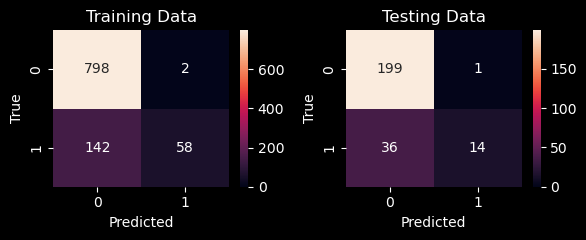

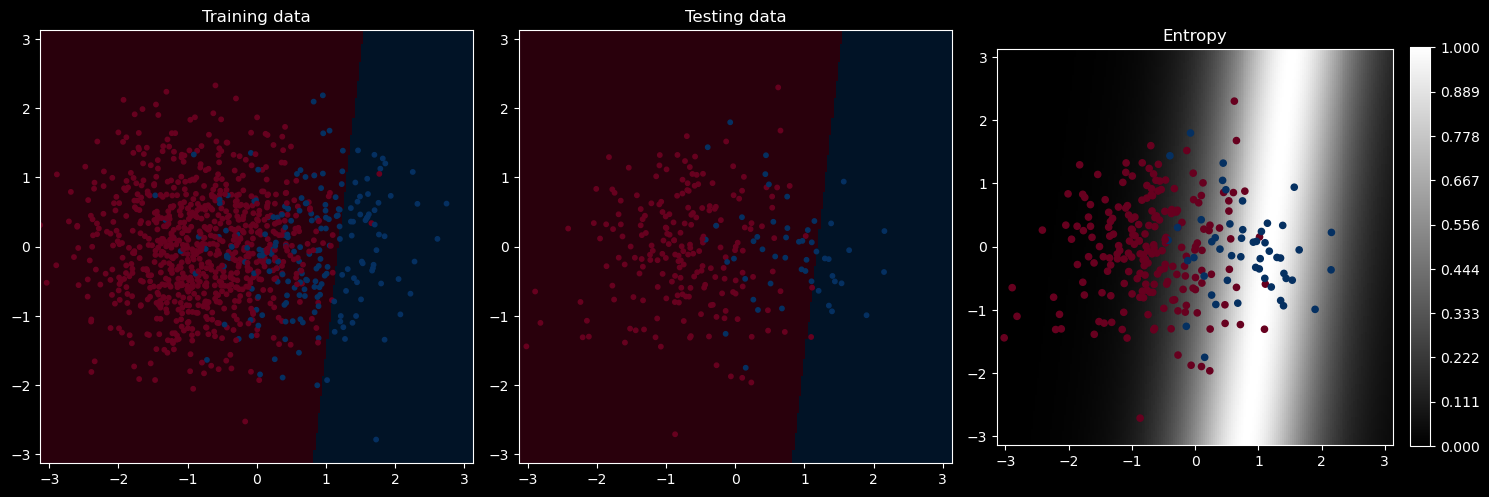



LogisticRegression(class_weight={0: np.float64(0.75), 1: np.float64(0.25)})
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       200
           1       0.91      0.40      0.56        50

    accuracy                           0.87       250
   macro avg       0.89      0.70      0.74       250
weighted avg       0.88      0.87      0.85       250



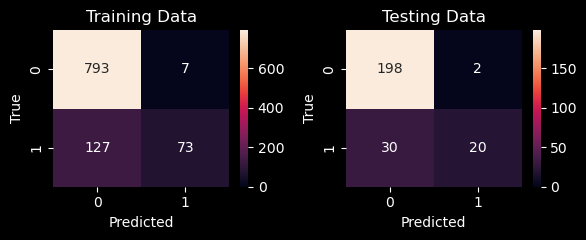

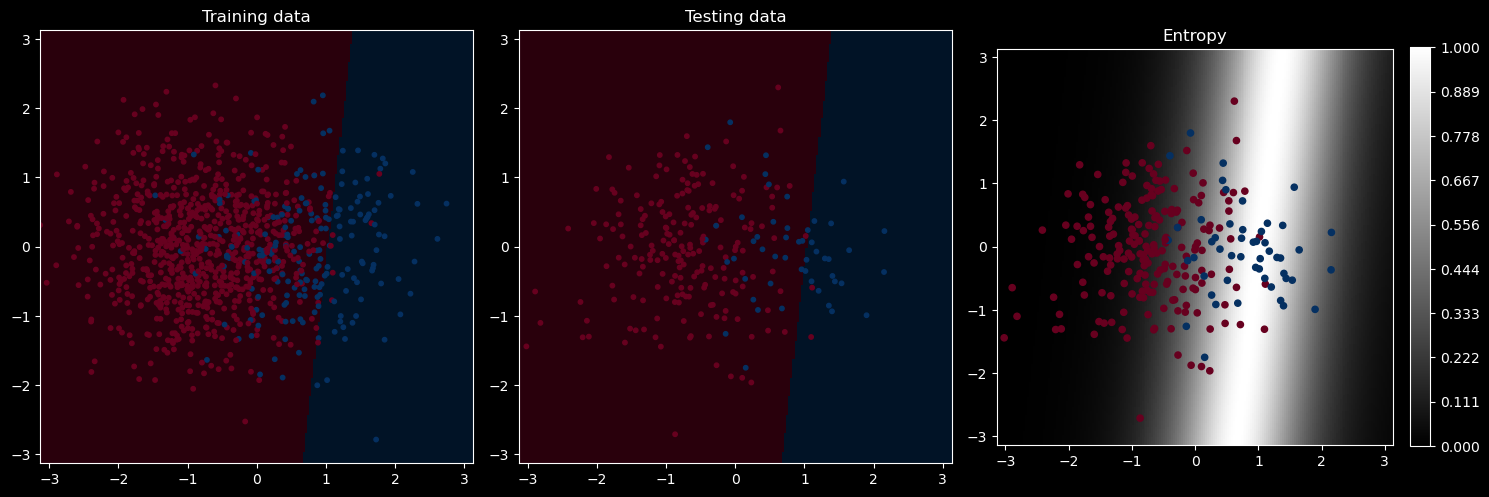



LogisticRegression(class_weight={0: np.float64(0.6875), 1: np.float64(0.3125)})
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       200
           1       0.89      0.48      0.62        50

    accuracy                           0.88       250
   macro avg       0.89      0.73      0.78       250
weighted avg       0.88      0.88      0.87       250



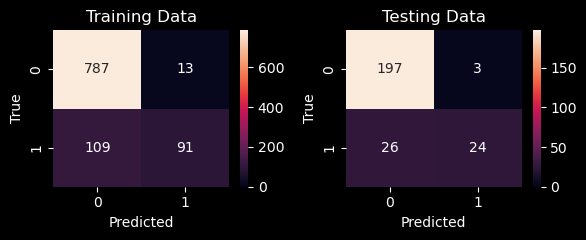

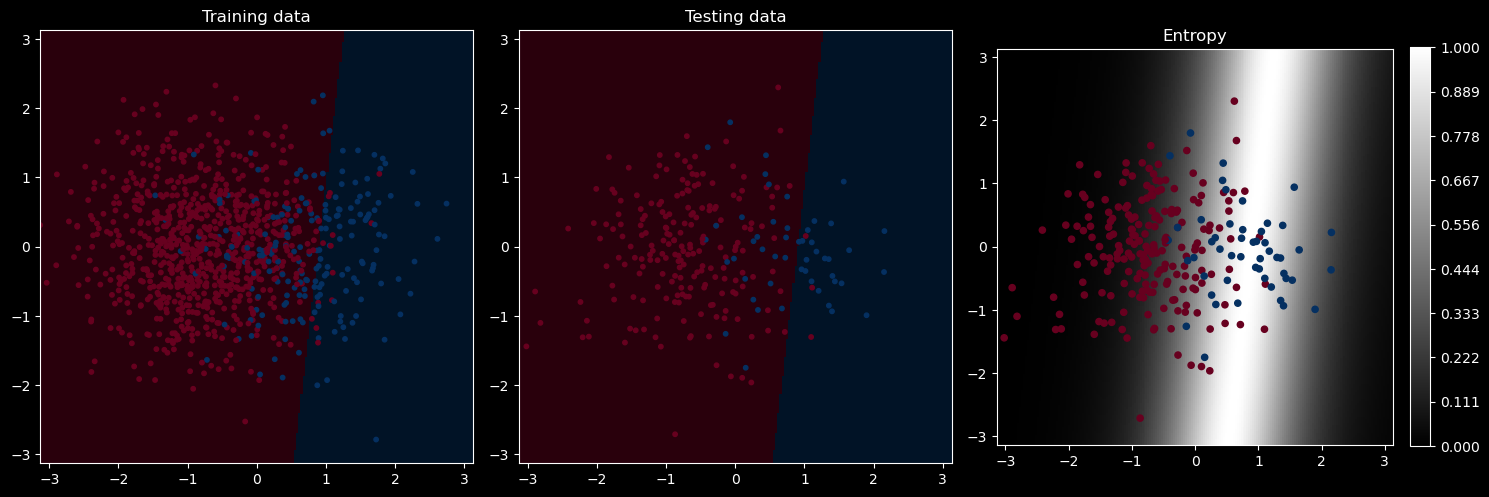



LogisticRegression(class_weight={0: np.float64(0.625), 1: np.float64(0.375)})
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       200
           1       0.86      0.48      0.62        50

    accuracy                           0.88       250
   macro avg       0.87      0.73      0.77       250
weighted avg       0.88      0.88      0.87       250



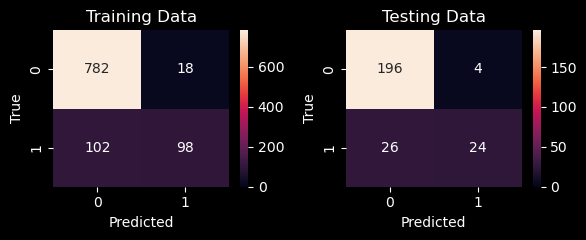

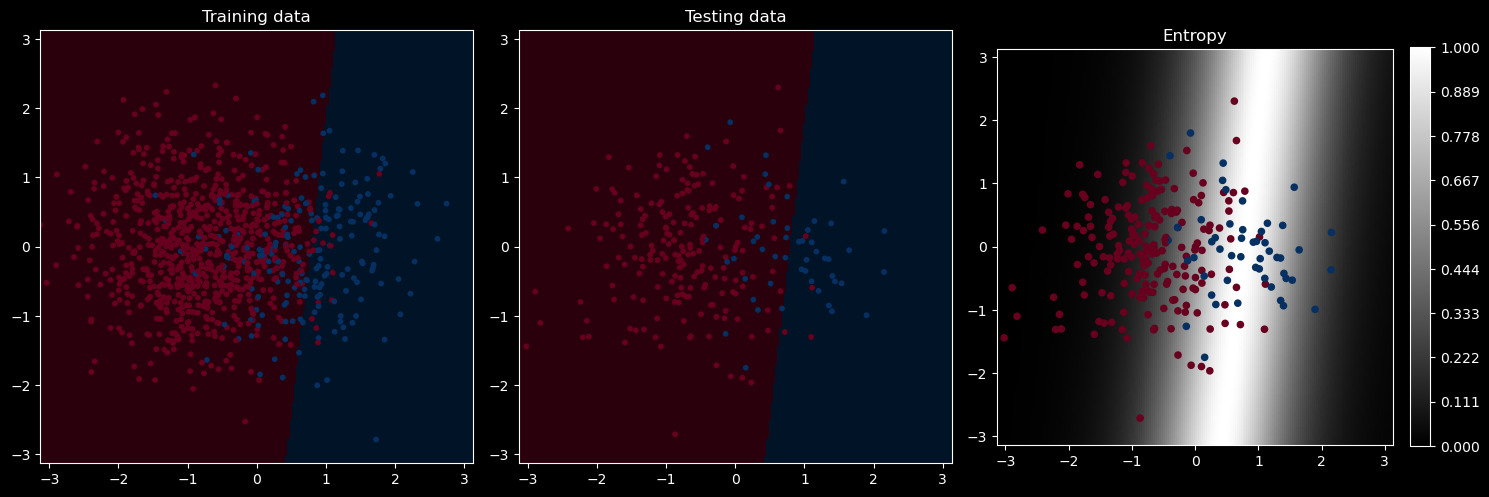



LogisticRegression(class_weight={0: np.float64(0.5625), 1: np.float64(0.4375)})
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       200
           1       0.82      0.56      0.67        50

    accuracy                           0.89       250
   macro avg       0.86      0.77      0.80       250
weighted avg       0.88      0.89      0.88       250



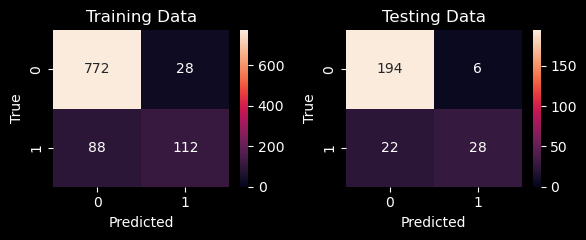

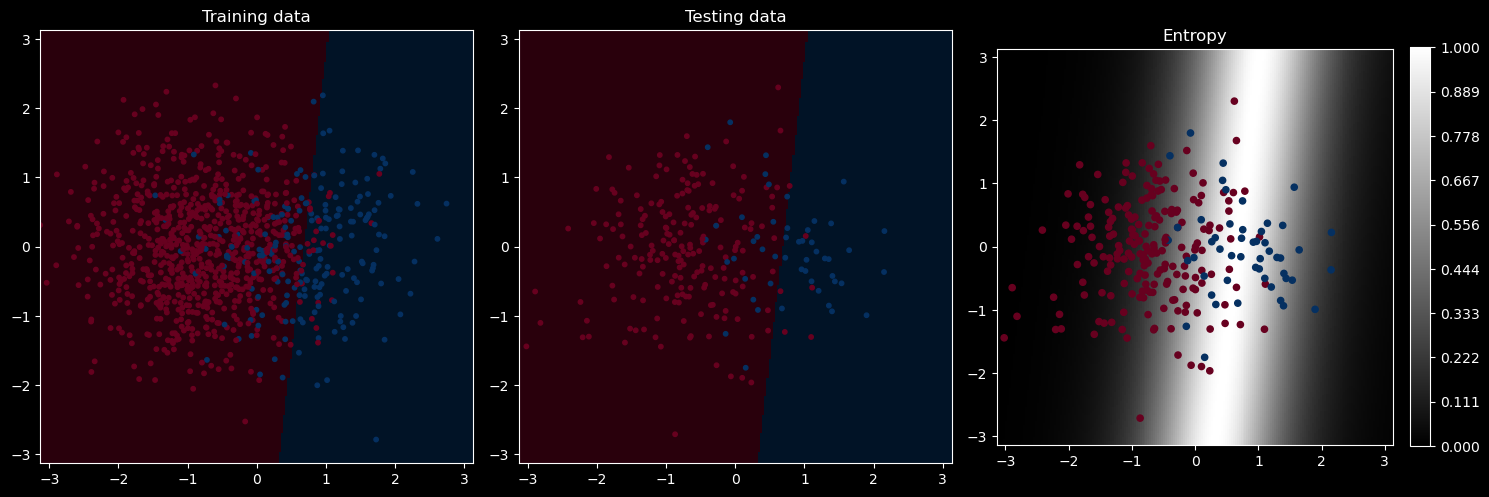



LogisticRegression(class_weight={0: np.float64(0.5), 1: np.float64(0.5)})
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       200
           1       0.77      0.60      0.67        50

    accuracy                           0.88       250
   macro avg       0.84      0.78      0.80       250
weighted avg       0.88      0.88      0.88       250



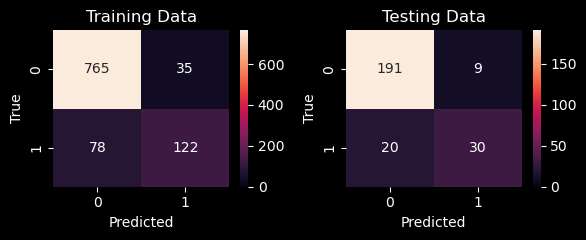

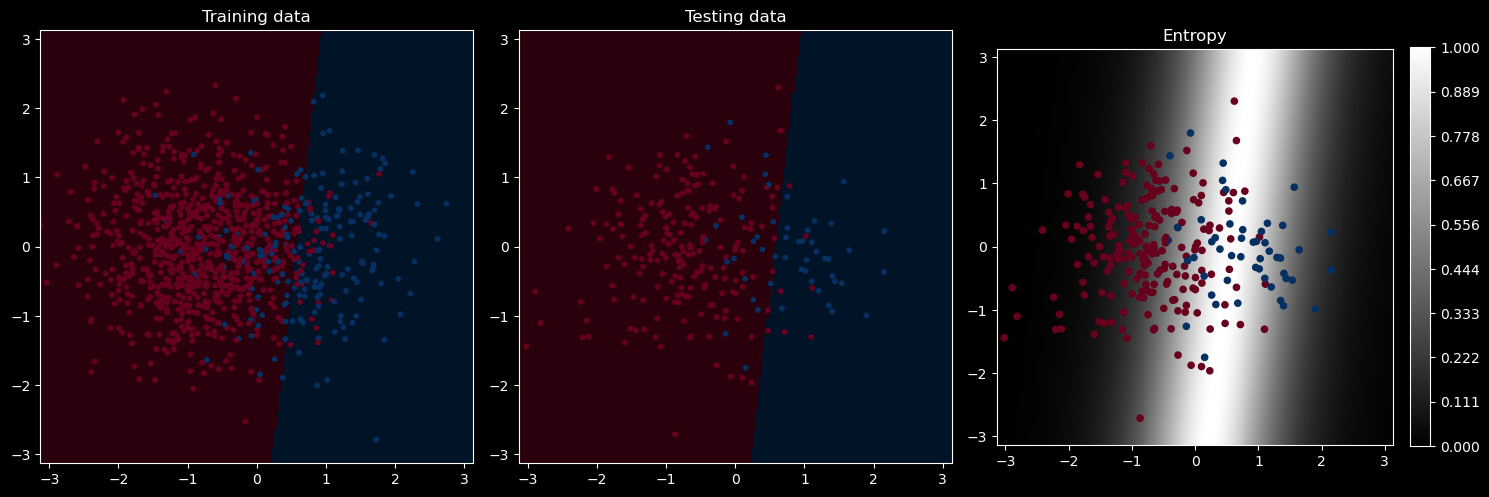



LogisticRegression(class_weight={0: np.float64(0.4375), 1: np.float64(0.5625)})
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       200
           1       0.74      0.64      0.69        50

    accuracy                           0.88       250
   macro avg       0.83      0.79      0.81       250
weighted avg       0.88      0.88      0.88       250



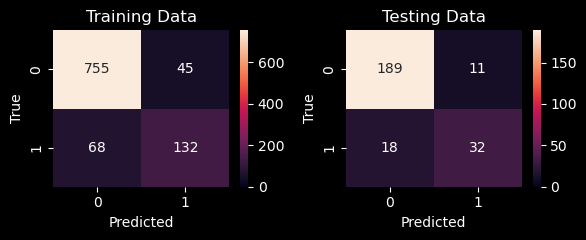

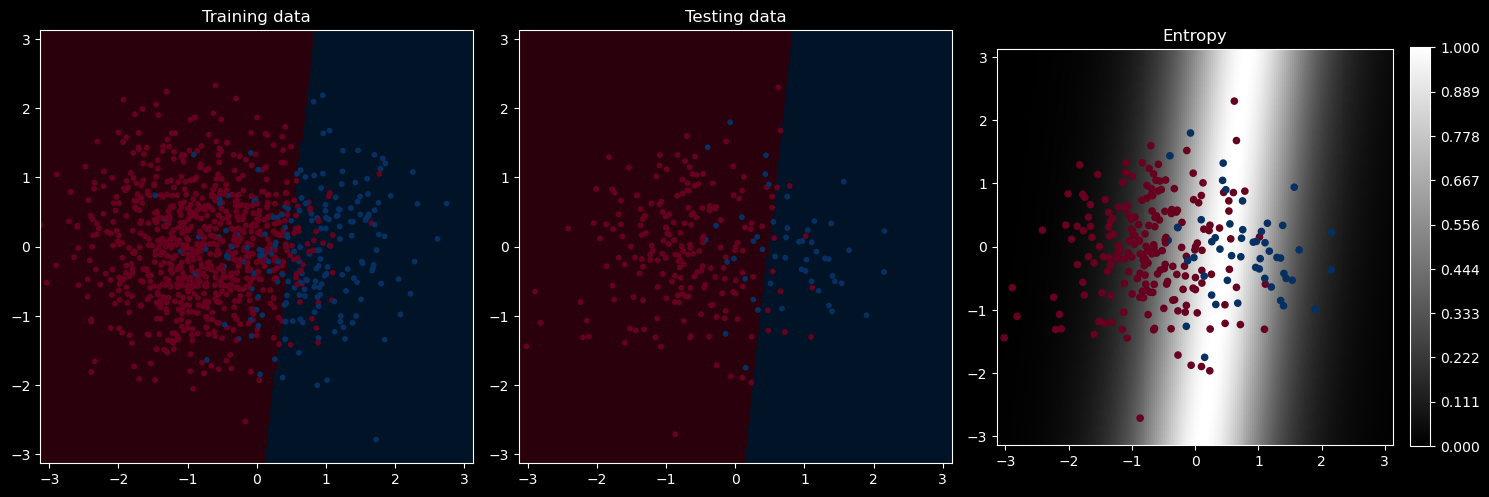



LogisticRegression(class_weight={0: np.float64(0.375), 1: np.float64(0.625)})
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       200
           1       0.69      0.70      0.69        50

    accuracy                           0.88       250
   macro avg       0.81      0.81      0.81       250
weighted avg       0.88      0.88      0.88       250



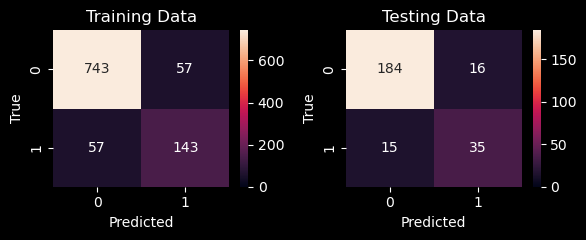

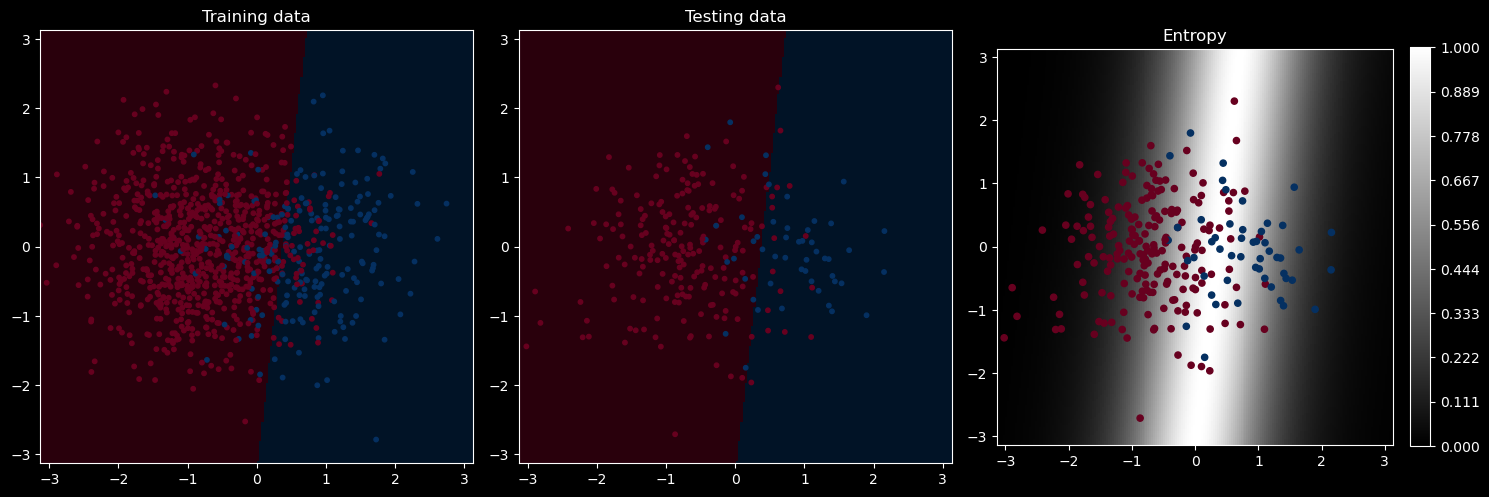



LogisticRegression(class_weight={0: np.float64(0.3125), 1: np.float64(0.6875)})
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       200
           1       0.66      0.82      0.73        50

    accuracy                           0.88       250
   macro avg       0.81      0.86      0.83       250
weighted avg       0.89      0.88      0.88       250



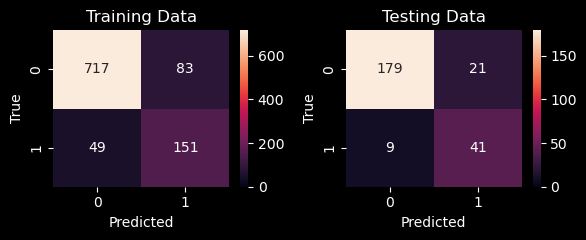

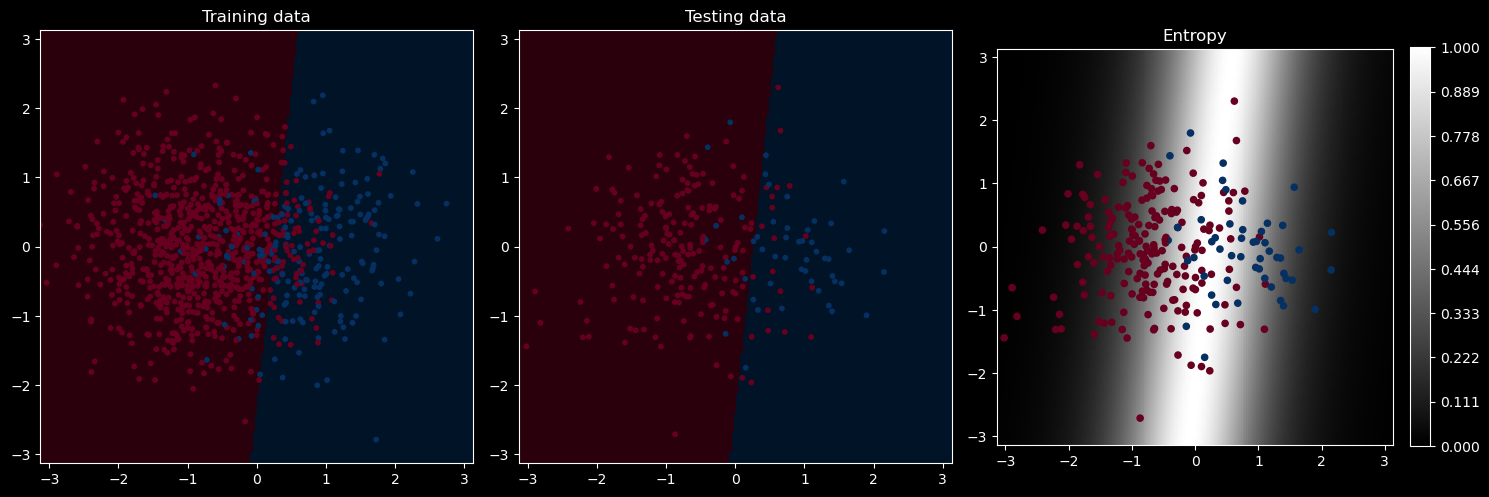



LogisticRegression(class_weight={0: np.float64(0.25), 1: np.float64(0.75)})
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       200
           1       0.61      0.84      0.71        50

    accuracy                           0.86       250
   macro avg       0.78      0.85      0.81       250
weighted avg       0.89      0.86      0.87       250



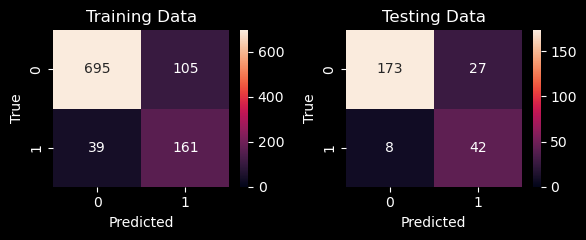

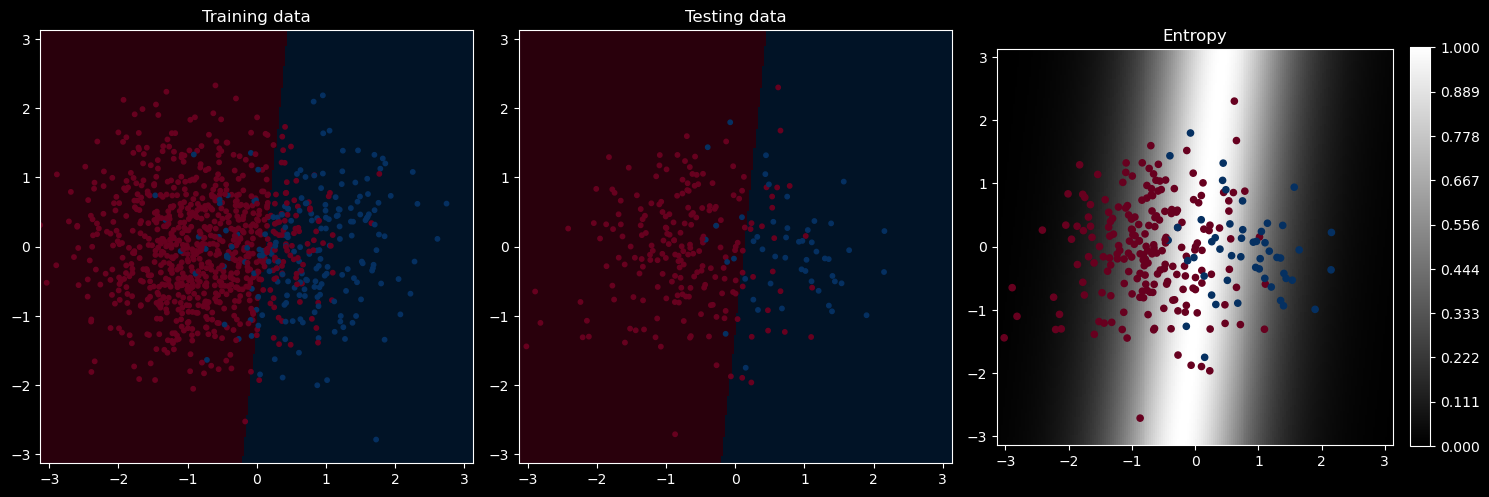



LogisticRegression(class_weight={0: np.float64(0.1875), 1: np.float64(0.8125)})
              precision    recall  f1-score   support

           0       0.97      0.81      0.88       200
           1       0.54      0.90      0.68        50

    accuracy                           0.83       250
   macro avg       0.76      0.85      0.78       250
weighted avg       0.88      0.83      0.84       250



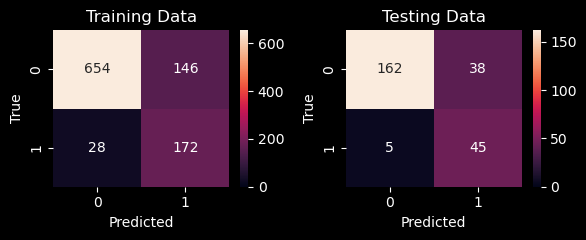

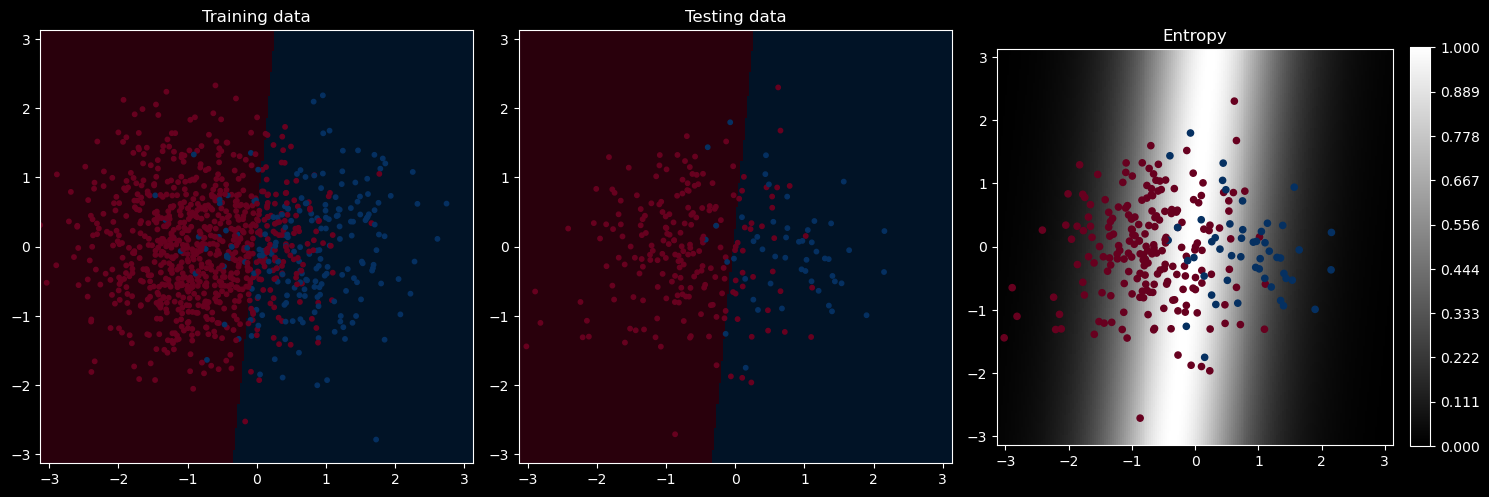



LogisticRegression(class_weight={0: np.float64(0.125), 1: np.float64(0.875)})
              precision    recall  f1-score   support

           0       0.98      0.74      0.84       200
           1       0.47      0.94      0.63        50

    accuracy                           0.78       250
   macro avg       0.73      0.84      0.74       250
weighted avg       0.88      0.78      0.80       250



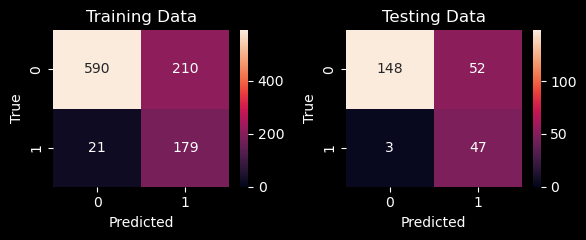

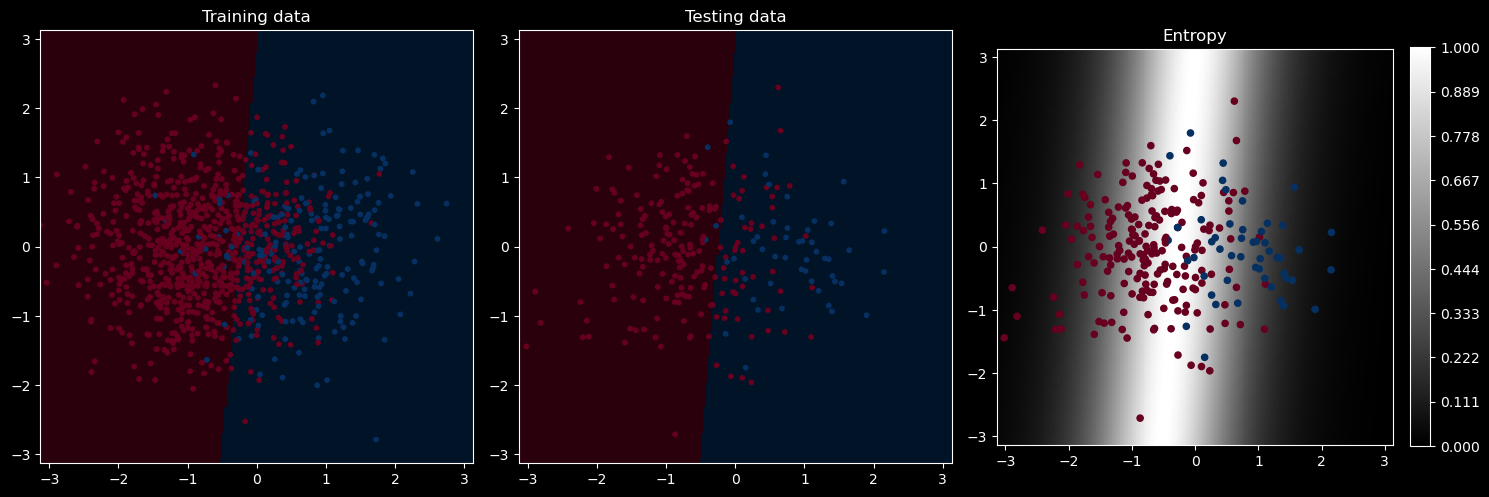



LogisticRegression(class_weight={0: np.float64(0.0625), 1: np.float64(0.9375)})
              precision    recall  f1-score   support

           0       1.00      0.59      0.75       200
           1       0.38      1.00      0.55        50

    accuracy                           0.68       250
   macro avg       0.69      0.80      0.65       250
weighted avg       0.88      0.68      0.71       250



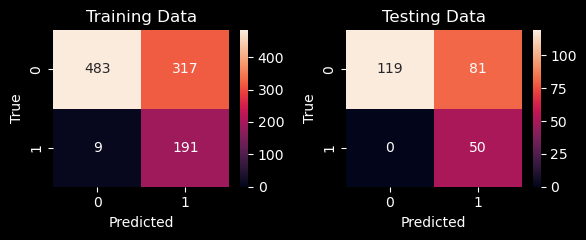

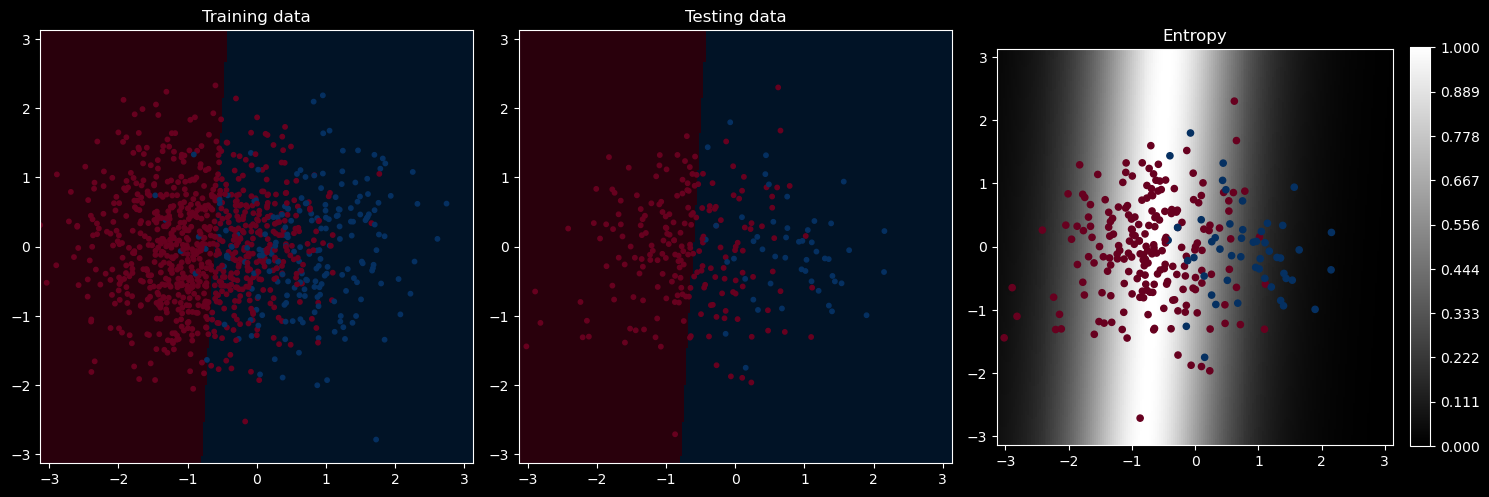

In [6]:
pre = np.zeros((n_plot,2))
rec = np.zeros((n_plot,2))
f1  = np.zeros((n_plot,2))

confs = []
for i in range(n_plot):
    class_weight = {
        0:1-w[i], # negative class
        1:w[i]    # positive class
    }
    model = LogisticRegression(class_weight=class_weight)
    #model = RandomForestClassifier(n_estimators=100, max_leaf_nodes=10, class_weight=class_weight)
    model.fit(X_train, y_train)
    print(model)
    
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    print(classification_report(y_test, y_test_pred))
    
    conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)
    confs.append(conf_matrix_test)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))
    
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    plt.tight_layout()
    plt.show()

    B, S = visualize_regions(model, MAX, 200)
    
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
    
    extent = [-MAX,MAX,-MAX,MAX]
    
    cmap = "RdBu"
    axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
    axes[0].set_aspect('equal')
    axes[0].set_title('Training data');
    
    axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
    axes[1].set_aspect('equal')
    axes[1].set_title('Testing data');
    
    im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
    axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
    axes[2].set_aspect('equal')
    axes[2].set_title('Entropy')
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

    plt.tight_layout()
    plt.show()
    
    p, r, f, s = precision_recall_fscore_support(y_test, y_test_pred)
    
    pre[i,0] = p[0]
    pre[i,1] = p[1]
    
    rec[i,0] = r[0]
    rec[i,1] = r[1]
    
    f1[i,0] = f[0]
    f1[i,1] = f[1]

    print()
    print()
# end
confs = np.array(confs)

The plot is the heart of the notebook. As $w_1$ increases:

- **Recall on class 1 rises** — the model predicts the minority class more freely, so it catches more
  of them.
- **Precision on class 1 falls** — it also flags more false positives.
- **Class 0's curves move the opposite way**, since every point predicted as class 1 is one not
  predicted as class 0.

The two solid-and-dashed families crossing is the trade-off made visible. **No point on this plot is
objectively best.** $F_1$ picks one, but only because it happens to weight precision and recall
equally — which is an assumption about the application, not a fact about the model.

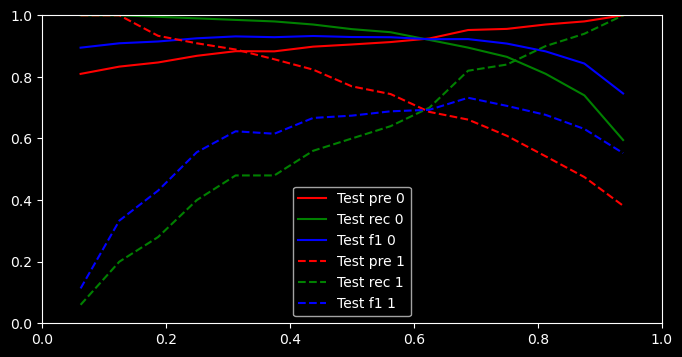

In [7]:
plt.figure(figsize=(8,4));

plt.plot( w, pre[:,0], 'r', label='Test pre 0' )
plt.plot( w, rec[:,0], 'g', label='Test rec 0' )
plt.plot( w, f1[:,0],  'b', label='Test f1 0' )
plt.plot( w, pre[:,1], 'r--', label='Test pre 1' )
plt.plot( w, rec[:,1], 'g--', label='Test rec 1' )
plt.plot( w, f1[:,1],  'b--', label='Test f1 1' )
plt.xlim(0,1)
plt.ylim(0,1)
plt.legend()

## 4. Choosing a weight with a reward matrix

If $F_1$'s implicit "precision and recall matter equally" is an assumption, the way out is to state
the real assumption explicitly. A **reward matrix** assigns a value to each cell of the confusion
matrix:

$$R = \begin{bmatrix} R_{TN} & R_{FP} \\ R_{FN} & R_{TP} \end{bmatrix}$$

and the total value of a model is the elementwise product with its confusion matrix, summed:

$$\text{reward} = \sum_{i,j} C_{ij} R_{ij}$$

The matrix used here says a false negative costs $-5000$, a false positive costs $-100$, a true
positive earns $+1000$, and a true negative is free. That encodes a specific world — missing a
positive case is fifty times worse than a false alarm — which is typical of screening problems where
a missed case is a serious harm and a false alarm is a follow-up test.

Now the sweep has an objective answer: pick the $w$ that maximizes total reward. Note the optimum
generally sits **away** from the $F_1$-maximizing point, because $F_1$ never knew about the 50:1
asymmetry. This is the most transferable idea in the notebook — when a metric cannot decide, it is
usually because the decision belongs to the application.

## Applied example to decide which weights to use (reward matrix)

[  -1700    6000    5400    7000    6400    1400   -4200  -17000  -24800
  -46500  -64900  -93800 -145500 -213300 -355000]


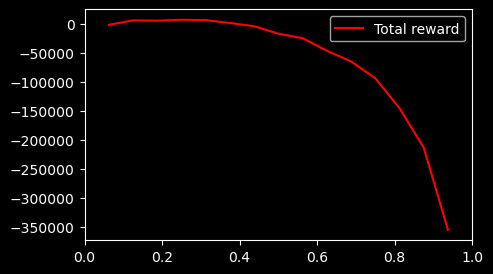

Optimal weight for max reward: 0.25


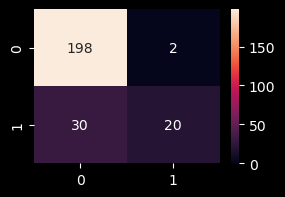

In [8]:
reward_matrix = np.array(
    [[   0, -5000],
     [   -100,  1000]]
)

rewards = []
for conf in confs:
    rewards.append( (conf * reward_matrix).sum() )
# end
rewards = np.array(rewards)
print(rewards)

plt.figure(figsize=(5,3));
plt.plot( w, rewards, 'r', label='Total reward' )
plt.xlim(0,1)
plt.legend()
plt.show()

idx_max = np.argmax(rewards)
print("Optimal weight for max reward:", w[idx_max])

plt.figure(figsize=(3,2));
sns.heatmap(confs[idx_max], annot=True, vmin=0, fmt='d')
plt.show()

## 5. Inverse-frequency weights

The common default. `class_weight='balanced'` sets each class's weight inversely to its frequency:

$$w_c = \frac{n}{K \cdot n_c}$$

for $n$ samples, $K$ classes and $n_c$ in class $c$. Every class then contributes equally in total,
regardless of size — it is the class-weight equivalent of resampling to equal counts, achieved
without touching the data.

The cell shows both routes: the explicit dictionary built from $1/n_c$ and normalized, and the
`'balanced'` keyword that computes it for you. They agree, and the commented line lets you swap
between them.

Worth being clear about what this is: `'balanced'` is a **reasonable default, not an optimum**. It
answers "make the classes count equally", which is a different question from "maximize reward", and
section 4 is the one that answers the question you probably care about.

## Inverse frequency class weights

{0: np.float64(0.2), 1: np.float64(0.8)}
LogisticRegression(class_weight='balanced')
              precision    recall  f1-score   support

           0       0.96      0.81      0.88       200
           1       0.54      0.88      0.67        50

    accuracy                           0.83       250
   macro avg       0.75      0.85      0.78       250
weighted avg       0.88      0.83      0.84       250



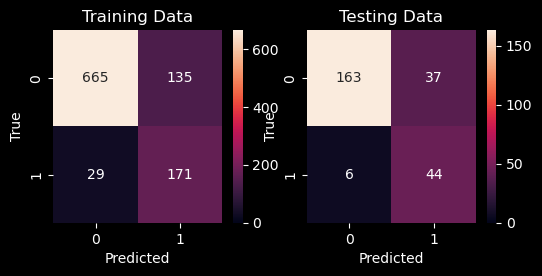

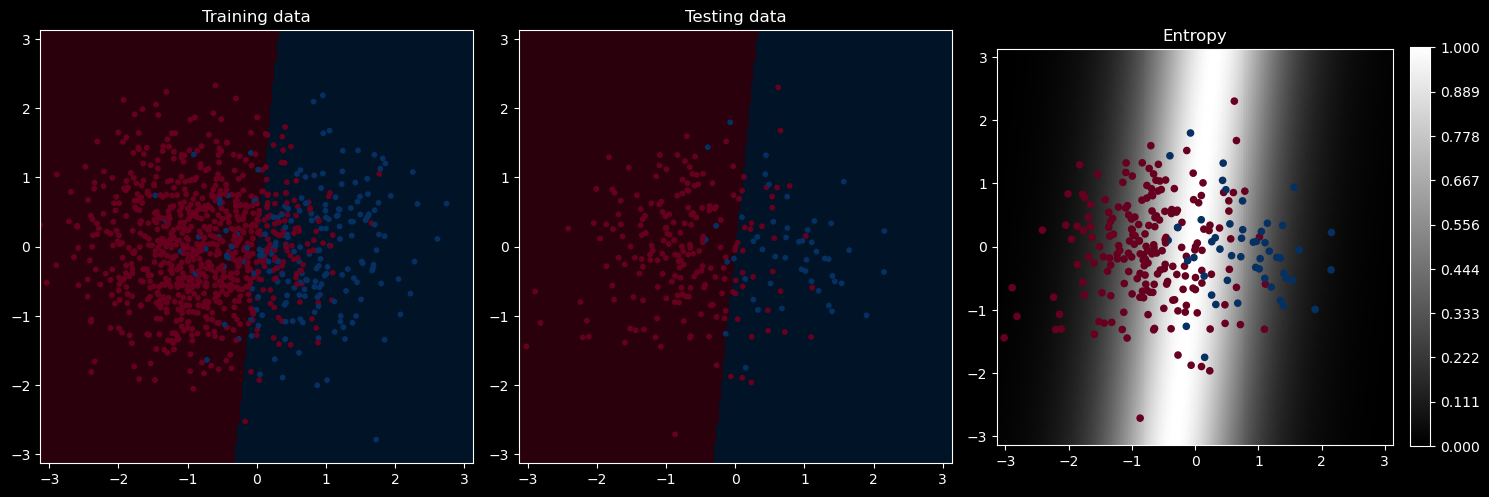

In [9]:
class_weight = np.array([1.0/n_pts0, 1.0/n_pts1])
class_weight = class_weight / class_weight.sum()
class_weight = { 0:class_weight[0], 1:class_weight[1] }
print(class_weight)

model = LogisticRegression(
    #class_weight=class_weight
    class_weight='balanced'
)

model.fit(X_train, y_train)
print(model)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print(classification_report(y_test, y_test_pred))

conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Training Data")

sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Testing Data")

plt.show()

B, S = visualize_regions(model, MAX, 200)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

extent = [-MAX,MAX,-MAX,MAX]

cmap = "RdBu"
axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
axes[0].set_aspect('equal')
axes[0].set_title('Training data');

axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
axes[1].set_aspect('equal')
axes[1].set_title('Testing data');

im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
axes[2].set_aspect('equal')
axes[2].set_title('Entropy')
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

plt.tight_layout()
plt.show()

## 6. Review

- **Class weighting rebalances the loss rather than the data**: $\mathcal{L} = -\sum_i w_{y_i}\log \hat{p}^{(i)}_{y_i}$.
  Nothing is duplicated or discarded.
- **Only the ratio of the weights matters**, not their scale.
- **Sweeping the weight traces the precision/recall trade-off** — minority recall up, minority
  precision down — and no point on that curve is objectively best.
- **A reward matrix makes the choice objective** by pricing each confusion-matrix cell:
  $\text{reward} = \sum_{ij} C_{ij}R_{ij}$. Its optimum usually differs from the $F_1$ optimum,
  because $F_1$ assumes a symmetry the application may not have.
- **`class_weight='balanced'` uses $w_c = n/(K n_c)$** — a sensible default that makes classes count
  equally, not an optimum for any particular cost structure.